# SMOTE y ADASYN: técnicas de sobremuestreo sintético para datos desbalanceadosEste cuaderno explica en detalle **SMOTE** (Synthetic Minority Over-sampling Technique) y **ADASYN** (Adaptive Synthetic Sampling), dos técnicas ampliamente usadas para tratar el desbalance de clases en aprendizaje automático.

## 1. El problema: desbalance de clasesEn muchos problemas de clasificación reales aparecen **conjuntos desbalanceados**: una clase (la *minoritaria*) tiene muchas menos observaciones que la otra (la *mayoritaria*).**Ejemplos:**- Detección de fraude: 99,9 % transacciones legítimas, 0,1 % fraude- Diagnóstico médico: enfermedades raras frente a pacientes sanos- Detección de spam: pocos correos spam entre muchos legítimos**¿Por qué es un problema?**- Los clasificadores habituales optimizan la *accuracy* global, que se puede lograr prediciendo siempre la clase mayoritaria- El modelo puede no aprender los patrones de la clase minoritaria- Métricas como la accuracy engañan (por ejemplo, 99,9 % de acierto prediciendo siempre «no fraude»)

### Configuración: instalar dependencias (en Colab normalmente solo falta `imbalanced-learn`)

In [1]:
# Instalar imbalanced-learn si no está disponible
try:
    import imblearn
except ImportError:
    !pip install -q imbalanced-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# Estilo robusto: prueba varias opciones según la versión de matplotlib
for estilo in ['seaborn-v0_8-whitegrid', 'seaborn-whitegrid', 'ggplot', 'default']:
    try:
        plt.style.use(estilo)
        break
    except OSError:
        continue

sns.set_palette("husl")
np.random.seed(42)

### Crear un conjunto desbalanceado para la demostración

In [3]:
# Conjunto desbalanceado con DOS clústeres por clase para que la minoritaria
# tenga estructura más interesante (ahí es donde ADASYN puede destacar).
X, y = make_classification(
    n_samples=1500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    weights=[0.93, 0.07],
    flip_y=0.02,
    class_sep=0.9,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Distribución de clases en el conjunto de entrenamiento:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nClase minoritaria: {np.sum(y_train == 1)} muestras ({100*np.mean(y_train):.1f}%)")
print(f"Clase mayoritaria: {np.sum(y_train == 0)} muestras ({100*(1-np.mean(y_train)):.1f}%)")

Distribución de clases en el conjunto de entrenamiento:
0    973
1     77
Name: count, dtype: int64

Clase minoritaria: 77 muestras (7.3%)
Clase mayoritaria: 973 muestras (92.7%)


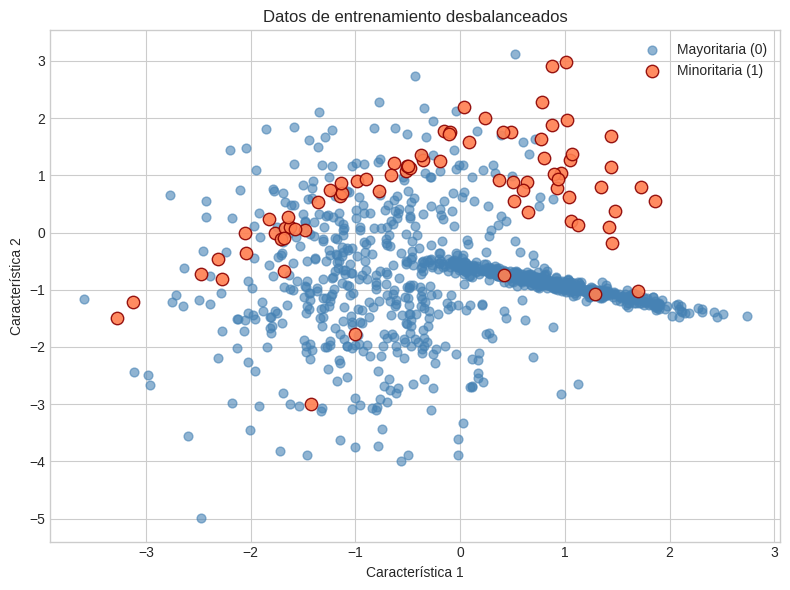

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
           c='steelblue', alpha=0.6, label='Mayoritaria (0)', s=40)
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
           c='coral', alpha=0.9, label='Minoritaria (1)', s=80, edgecolors='darkred')
ax.set_xlabel('Característica 1')
ax.set_ylabel('Característica 2')
ax.set_title('Datos de entrenamiento desbalanceados')
ax.legend()
plt.tight_layout()
plt.show()

---## 2. SMOTE: Synthetic Minority Over-sampling Technique**SMOTE** fue propuesto por Chawla et al. (2002) y es uno de los métodos de sobremuestreo más utilizados.### Idea centralEn lugar de **duplicar** muestras minoritarias (lo que favorece el sobreajuste), SMOTE crea muestras **sintéticas** interpolando entre instancias minoritarias existentes. Así se amplía la región de decisión de la clase minoritaria de forma más informativa.

### Algoritmo SMOTE (paso a paso)Para cada muestra minoritaria $x_i$:1. **Encontrar los k vecinos más cercanos** de $x_i$ entre otras muestras minoritarias (típicamente k=5).2. **Elegir al azar un vecino** $x_{nn}$ entre esos k vecinos.3. **Crear una muestra sintética** sobre el segmento entre $x_i$ y $x_{nn}$:   $$x_{nuevo} = x_i + \lambda \cdot (x_{nn} - x_i)$$   donde $\lambda$ es un número aleatorio en (0, 1). El nuevo punto queda entre los dos originales.4. **Repetir** hasta alcanzar la proporción minoritaria:mayoritaria deseada.

### Parámetros de SMOTE| Parámetro | Descripción | Valor típico ||-----------|-------------|--------------|| `k_neighbors` | Número de vecinos más cercanos a considerar | 5 || `sampling_strategy` | Proporción objetivo (`'auto'` para equilibrio, o un float) | `'auto'` o 0.5 || `random_state` | Reproducibilidad | 42 |### Ventajas- Reduce el sobreajuste frente al sobremuestreo aleatorio (no hay copias exactas).- Genera muestras sintéticas diversas en el espacio de características.- Simple y efectivo en muchos problemas.### Limitaciones- Trata por igual todas las minoritarias (puede sobremuestrear regiones ya densas).- Puede crear sintéticas en zonas dominadas por la mayoritaria (ruido).- Asume espacio continuo (para datos categóricos existe SMOTE-NC).

In [5]:
# Aplicar SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Tras SMOTE - Distribución de clases en entrenamiento:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nTotal de muestras: {len(y_train_smote)} (antes: {len(y_train)})")

Tras SMOTE - Distribución de clases en entrenamiento:
0    973
1    973
Name: count, dtype: int64

Total de muestras: 1946 (antes: 1050)


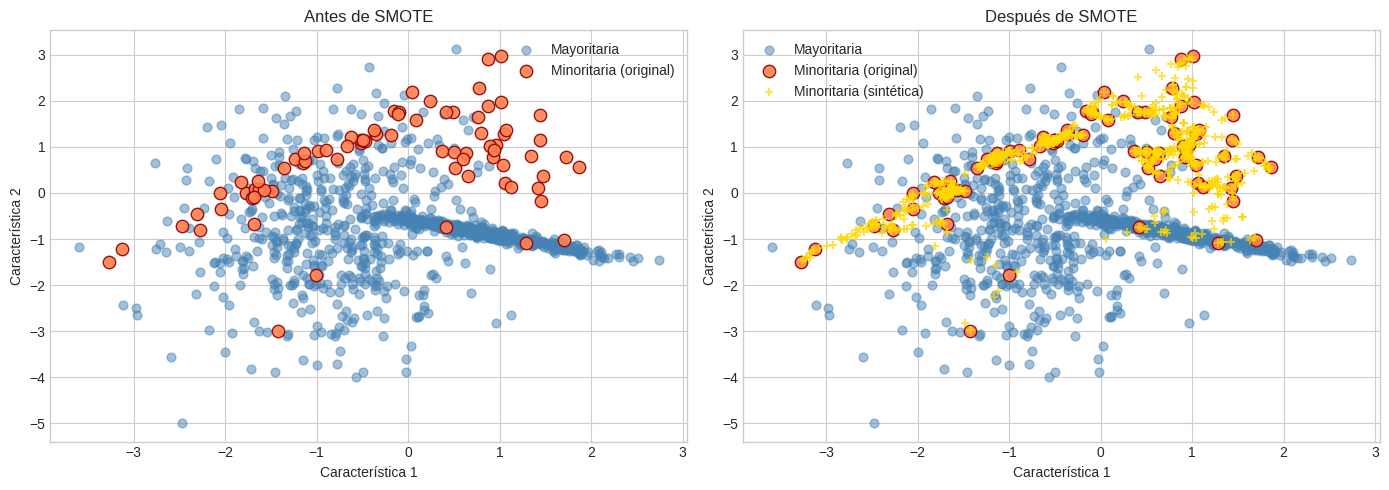

In [6]:
# Visualización: distinguir muestras minoritarias originales de las sintéticas
n_orig_min = int(np.sum(y_train == 1))
# imblearn agrega las muestras sintéticas al final de las originales
mascara_sinteticas = np.zeros(len(y_train_smote), dtype=bool)
indices_min = np.where(y_train_smote == 1)[0]
mascara_sinteticas[indices_min[n_orig_min:]] = True

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
                c='steelblue', alpha=0.5, label='Mayoritaria', s=40)
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
                c='coral', alpha=0.9, label='Minoritaria (original)', s=80, edgecolors='darkred')
axes[0].set_title('Antes de SMOTE')
axes[0].set_xlabel('Característica 1'); axes[0].set_ylabel('Característica 2')
axes[0].legend()

axes[1].scatter(X_train_smote[y_train_smote==0, 0], X_train_smote[y_train_smote==0, 1],
                c='steelblue', alpha=0.5, label='Mayoritaria', s=40)
axes[1].scatter(X_train_smote[(y_train_smote==1) & (~mascara_sinteticas), 0],
                X_train_smote[(y_train_smote==1) & (~mascara_sinteticas), 1],
                c='coral', alpha=0.9, label='Minoritaria (original)', s=80, edgecolors='darkred')
axes[1].scatter(X_train_smote[mascara_sinteticas, 0], X_train_smote[mascara_sinteticas, 1],
                c='gold', alpha=0.7, label='Minoritaria (sintética)', s=40, marker='+')
axes[1].set_title('Después de SMOTE')
axes[1].set_xlabel('Característica 1'); axes[1].set_ylabel('Característica 2')
axes[1].legend()

plt.tight_layout()
plt.show()

---## 3. ADASYN: Adaptive Synthetic Sampling**ADASYN** (He et al., 2008) es una extensión *adaptativa* de SMOTE. En lugar de tratar por igual todas las minoritarias, concentra la generación de sintéticas en instancias **difíciles de aprender**: rodeadas por mayoritarias o cerca de la frontera de decisión.

### En qué se diferencia ADASYN de SMOTE| Aspecto | SMOTE | ADASYN ||---------|-------|--------|| **Estrategia** | Uniforme: mismo número de sintéticas por minoritaria | Adaptativa: más sintéticas para muestras «difíciles» || **Enfoque** | Todas las minoritarias por igual | Minoritarias en el borde o difíciles de clasificar || **Ponderación** | Sin pesos | Cada minoritaria recibe un peso ∝ desbalance local || **Resultado** | Distribución uniforme de sintéticas | Más densidad de sintéticas cerca de la frontera |### Algoritmo ADASYN1. **Calcular el grado de desbalance** y el número total $G$ de muestras sintéticas a generar.2. **Para cada minoritaria** $x_i$, hallar sus $K$ vecinos (en todo el conjunto) y calcular $r_i$ = proporción de *mayoritarias* entre esos vecinos. Mayor $r_i$ ⇒ más difícil de clasificar.3. **Normalizar** los $r_i$ a pesos $\hat{r}_i$ que suman 1 (una distribución de densidad).4. **Para cada minoritaria**, generar $g_i = \hat{r}_i \cdot G$ sintéticas.5. **Cada sintética** se genera como en SMOTE: $x_{nuevo} = x_i + \lambda(x_{nn} - x_i)$.

### Cuándo usar ADASYN frente a SMOTE- **SMOTE** cuando las minoritarias están relativamente bien repartidas y se busca un refuerzo uniforme y simple.- **ADASYN** cuando la minoritaria tiene estructura compleja y hay muestras en «zonas de riesgo» (rodeadas por mayoritarias); ADASYN concentrará allí las sintéticas.- ⚠️ **Advertencia:** ADASYN puede amplificar el ruido si algunas minoritarias están mal etiquetadas o caen en zonas puramente mayoritarias, ya que justo ahí generará *más* muestras. Como punto de partida por defecto, SMOTE suele ser más seguro.

In [7]:
# Aplicar ADASYN
adasyn = ADASYN(n_neighbors=5, random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Tras ADASYN - Distribución de clases en entrenamiento:")
print(pd.Series(y_train_adasyn).value_counts().sort_index())
print(f"\nTotal de muestras: {len(y_train_adasyn)}")

Tras ADASYN - Distribución de clases en entrenamiento:
0    973
1    970
Name: count, dtype: int64

Total de muestras: 1943


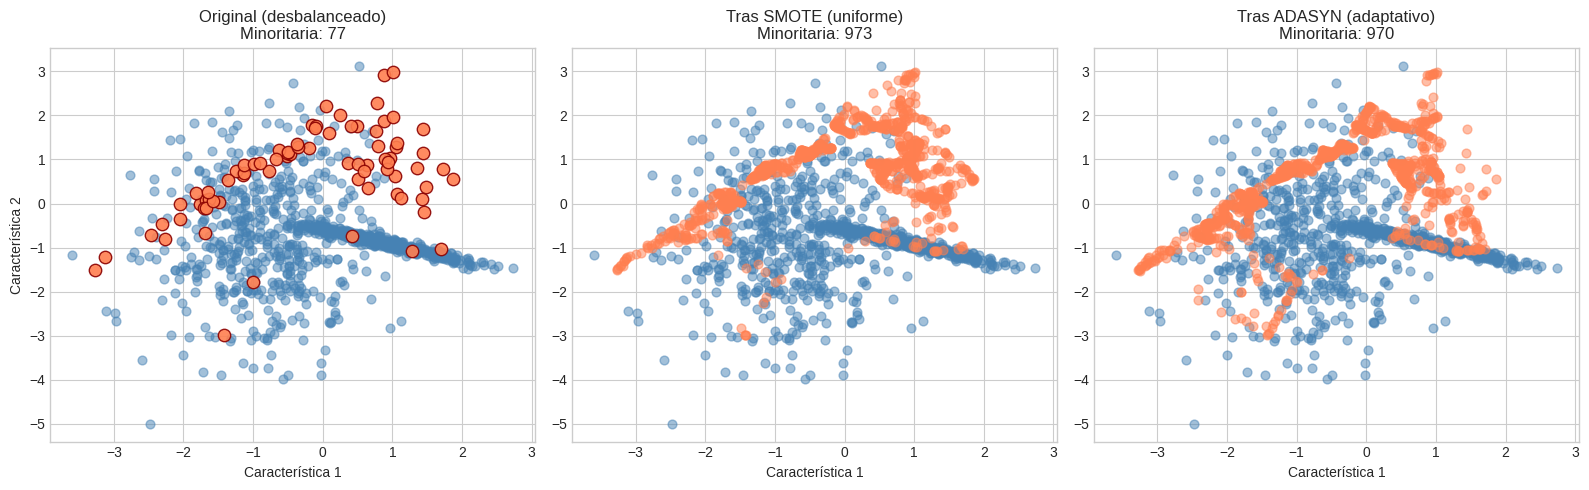

In [8]:
# Comparar: Original vs SMOTE vs ADASYN
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', alpha=0.5, s=40)
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', alpha=0.9, s=80, edgecolors='darkred')
axes[0].set_title(f'Original (desbalanceado)\nMinoritaria: {np.sum(y_train==1)}')
axes[0].set_xlabel('Característica 1'); axes[0].set_ylabel('Característica 2')

axes[1].scatter(X_train_smote[y_train_smote==0, 0], X_train_smote[y_train_smote==0, 1], c='steelblue', alpha=0.5, s=40)
axes[1].scatter(X_train_smote[y_train_smote==1, 0], X_train_smote[y_train_smote==1, 1], c='coral', alpha=0.5, s=40)
axes[1].set_title(f'Tras SMOTE (uniforme)\nMinoritaria: {np.sum(y_train_smote==1)}')
axes[1].set_xlabel('Característica 1')

axes[2].scatter(X_train_adasyn[y_train_adasyn==0, 0], X_train_adasyn[y_train_adasyn==0, 1], c='steelblue', alpha=0.5, s=40)
axes[2].scatter(X_train_adasyn[y_train_adasyn==1, 0], X_train_adasyn[y_train_adasyn==1, 1], c='coral', alpha=0.5, s=40)
axes[2].set_title(f'Tras ADASYN (adaptativo)\nMinoritaria: {np.sum(y_train_adasyn==1)}')
axes[2].set_xlabel('Característica 1')

plt.tight_layout()
plt.show()

---## 4. Comparación práctica: rendimiento del modeloEntrenamos el mismo clasificador sobre cada versión del conjunto y comparamos métricas en un *test* separado.

In [9]:
def entrenar_y_evaluar(X_tr, y_tr, nombre):
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_test)
    print(f"\n=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=['Mayoritaria', 'Minoritaria']))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    return f1_score(y_test, y_pred, pos_label=1)

f1_original = entrenar_y_evaluar(X_train,        y_train,        'Original (sin remuestreo)')
f1_smote    = entrenar_y_evaluar(X_train_smote,  y_train_smote,  'SMOTE')
f1_adasyn   = entrenar_y_evaluar(X_train_adasyn, y_train_adasyn, 'ADASYN')


=== Original (sin remuestreo) ===
              precision    recall  f1-score   support

 Mayoritaria       0.94      0.99      0.96       417
 Minoritaria       0.62      0.15      0.24        33

    accuracy                           0.93       450
   macro avg       0.78      0.57      0.60       450
weighted avg       0.91      0.93      0.91       450

Matriz de confusión:
[[414   3]
 [ 28   5]]

=== SMOTE ===
              precision    recall  f1-score   support

 Mayoritaria       0.98      0.84      0.91       417
 Minoritaria       0.29      0.82      0.43        33

    accuracy                           0.84       450
   macro avg       0.64      0.83      0.67       450
weighted avg       0.93      0.84      0.87       450

Matriz de confusión:
[[352  65]
 [  6  27]]

=== ADASYN ===
              precision    recall  f1-score   support

 Mayoritaria       0.99      0.81      0.89       417
 Minoritaria       0.26      0.85      0.39        33

    accuracy                

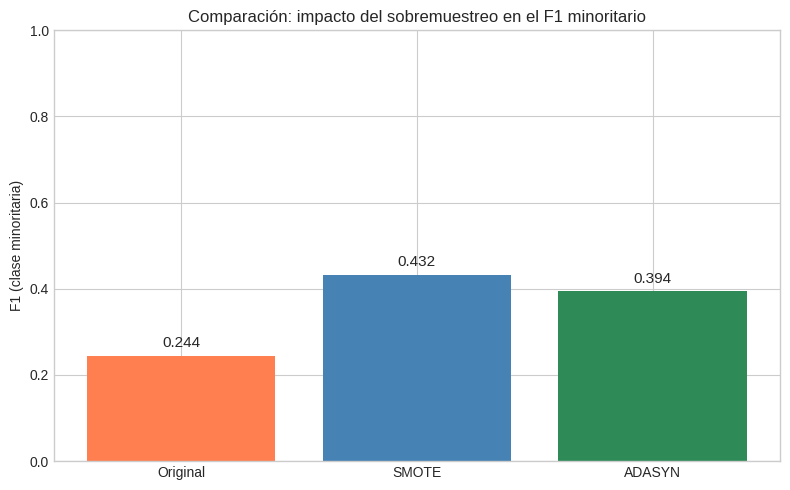

In [10]:
# Comparación de F1 en la clase minoritaria
fig, ax = plt.subplots(figsize=(8, 5))
metodos = ['Original', 'SMOTE', 'ADASYN']
f1_scores = [f1_original, f1_smote, f1_adasyn]
colors = ['coral', 'steelblue', 'seagreen']
bars = ax.bar(metodos, f1_scores, color=colors)
ax.set_ylabel('F1 (clase minoritaria)')
ax.set_title('Comparación: impacto del sobremuestreo en el F1 minoritario')
ax.set_ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---## 5. Resumen y buenas prácticas### Ideas clave1. **SMOTE** crea minoritarias sintéticas por interpolación lineal entre vecinos. Es uniforme y sencillo.2. **ADASYN** se adapta generando más sintéticas donde las minoritarias son más difíciles de clasificar (cerca de la frontera).3. **Aplicar el remuestreo solo al conjunto de entrenamiento**, nunca al de prueba, para evitar fugas de información (*data leakage*).4. **Usar pipelines** (por ejemplo `imblearn.pipeline.Pipeline`) para que el remuestreo ocurra correctamente dentro de cada pliegue de validación cruzada.5. **No confiar a ciegas en el sobremuestreo.** En algunos conjuntos, simplemente `class_weight='balanced'` o ajustar el umbral de decisión iguala o supera al sobremuestreo sintético — siempre conviene comparar.### Otras técnicas relacionadas- **Borderline-SMOTE:** sobremuestreo solo de minoritarias cerca de la frontera.- **SMOTE-ENN:** SMOTE + Edited Nearest Neighbors (elimina ruido).- **SMOTE-Tomek:** SMOTE + enlaces de Tomek (elimina mayoritarias conflictivas en el borde).- **Submuestreo:** `RandomUnderSampler`, Tomek Links, NearMiss.- **Combinado:** SMOTE + submuestreo en desbalances extremos.

In [11]:
# Ejemplo: pipeline (recomendado para validación cruzada correcta)
pipeline = ImbPipeline([
    ('smote', SMOTE(k_neighbors=5, random_state=42)),
    ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)
print("Pipeline (SMOTE + regresión logística) - Informe de clasificación:")
print(classification_report(y_test, y_pred_pipe, target_names=['Mayoritaria', 'Minoritaria']))

Pipeline (SMOTE + regresión logística) - Informe de clasificación:
              precision    recall  f1-score   support

 Mayoritaria       0.98      0.84      0.91       417
 Minoritaria       0.29      0.82      0.43        33

    accuracy                           0.84       450
   macro avg       0.64      0.83      0.67       450
weighted avg       0.93      0.84      0.87       450



---### Referencias- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *SMOTE: Synthetic Minority Over-sampling Technique.* Journal of Artificial Intelligence Research, 16, 321–357.- He, H., Bai, Y., Garcia, E. A., & Li, S. (2008). *ADASYN: Adaptive synthetic sampling approach for imbalanced learning.* IEEE International Joint Conference on Neural Networks (IJCNN), 1322–1328.